# 1. K-means
* ML programming practice series
* Author: Shir-Kang Scott, Jin (email: chinssk@gmail.com)
## Main reference:
* Arthur, David, and Sergei Vassilvitskii. k-means++: The Advantages of Careful Seeding. Proceedings of the Eighteenth Annual ACM-SIAM Symposium on Discrete Algorithms (SODA ’07), Society for Industrial and Applied Mathematics, New Orleans, Louisiana, 2007, pp. 1027–1035.


## Basic Concept
### k-means
#### What does it do?
K-means is a simple clustering method that tries to separate a dataset into “K” clusters, in which the data points are grouped so that each point belongs to the cluster with the nearest mean (centroid), and the algorithm iteratively refines these clusters until they stabilize.

#### Basic algorithm
1. Select K centers.
2. Randomly choose k points.
3. Iterate until stabilize: \
3.1. Assign all the points to their nearest Centroids.\
3.2. Find the center(mean) possition of the cluster as the new Centroid.\



In [27]:
# Imports
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_iris
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

## Dataset
* For the dataset let us use a synthetic dataset
* We make use of the make_blobs function
* We create 3 groups of data point(dp), each group has 100 dp, and each of them has 2 feats.

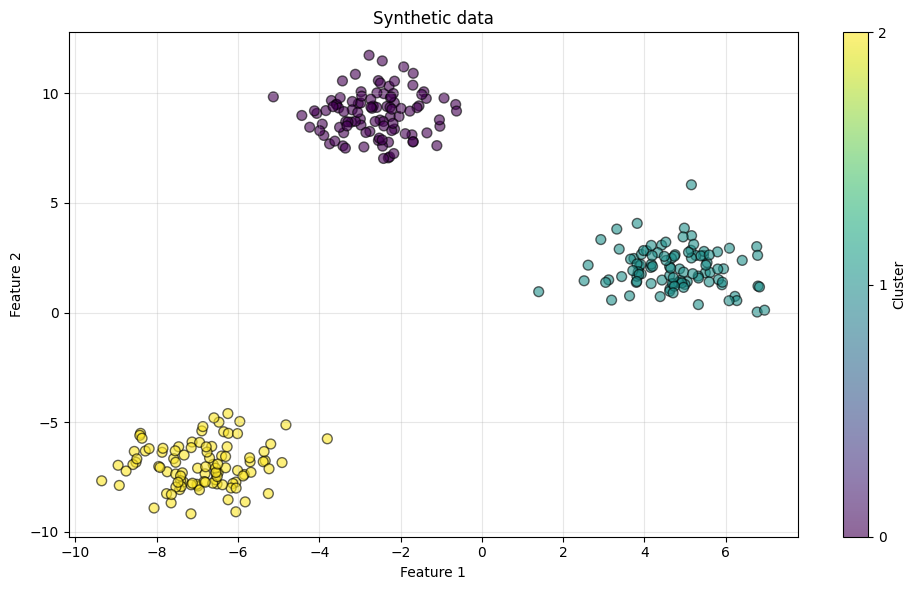

Data shape: (300, 2)
Number of clusters: 3
Cluster distribution: {np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100)}


In [28]:



# (X: Data points (n_samples, n_features)), ( Y: Group (n_samples ))
# Create 300 data points with 2 features, 3 centers.
X, Y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)


# Create the plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', s=50, alpha=0.6, edgecolors='k')
cbar = plt.colorbar(scatter, label='Cluster', ticks=[0, 1, 2])
cbar.set_ticklabels(['0', '1', '2'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic data')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Data shape: {X.shape}")
print(f"Number of clusters: {len(set(Y))}")
print(f"Cluster distribution: {dict(zip(*np.unique(Y, return_counts=True)))}")



## Basic Version


In [29]:
class KMeans(nn.Module):
    """
    Basic K-means algorithm
    """
    def __init__(self, k, device='cuda' if torch.cuda.is_available() else 'cpu'):
        super().__init__()
        self.k = k
        self.device = device

    def select_init_center(self, x):
        # Random select, we will change this later
        x = x.to(self.device)
        # Random permute the size of input and pick the first k to be the initial centroids
        return x[torch.randperm(x.size(0), device=self.device)[:self.k]].clone()


    def _assign_center(self, x, centers):
        distances = torch.cdist(x, centers)
        return torch.argmin(distances, dim=1)

    def _update_center(self, x, cluster_member):
        # Vectorized, naiively you can do a loop, but this is pytorch!
        # given x is (num_point, num_feat), cluster_member(num_point)
        new_centers = torch.zeros(self.k, x.size(1), dtype=torch.float, device=self.device) #(k, num_feat)
        # How may points each cluster have?
        counts = torch.bincount(cluster_member, minlength=self.k).float() # (k)

        # Sum all points for each cluster
        # Tensor.scatter_add_(dim, index, src)
        # unsqueeze and expand makes the cluster_member(num_points, 2)
        new_centers.scatter_add_(0, cluster_member.unsqueeze(1).expand(-1, x.size(1)), x)
        # Divide by counts to get means
        # Yes this will make the result inaccurate if the cluster has no points,
        # but helps with safety
        counts = counts.clamp(min=1).unsqueeze(1)
        # Divide the sum by number of points
        new_centers = new_centers / counts

        return new_centers

    def forward(self, x, centers):
        x = x.to(self.device)
        cluster_member = self._assign_center(x, centers)
        new_centers = self._update_center(x, cluster_member)
        return cluster_member, new_centers



## Evaluation Criteria
* Here we use Within-Cluster Sum of Squares (WCSS) as the criteria
* It is calculated as the sum of distance to the centroid


In [30]:

def wcss( x, cluster_member, centers):
    """
    Calculate Within-Cluster Sum of Squares
    """
    # Distance from each point to its assigned center
    # this will create (num_point, num_feats), with the centers,
    # so that we can calculate the distance of each to their centers
    assigned_centers = centers[cluster_member]
    squared_distances = ((x - assigned_centers) ** 2).sum(dim=1)

    return squared_distances.sum()

## Evaluation

In [34]:
# Settings
iteration = 100
k_max = 10
results = []

# run
for k in range(1, k_max+1):

    # Create model
    model = KMeans(k)
    X_tensor = torch.from_numpy(X).type(torch.float)
    # Select starting centroids
    new_centers = model.select_init_center(X_tensor)

    # loop
    for i in range(iteration):
        cluster_member, new_centers = model(X_tensor, new_centers)

    result = wcss(X_tensor, cluster_member, new_centers)  # calulate score
    results.append(result.item()) # cast back to python


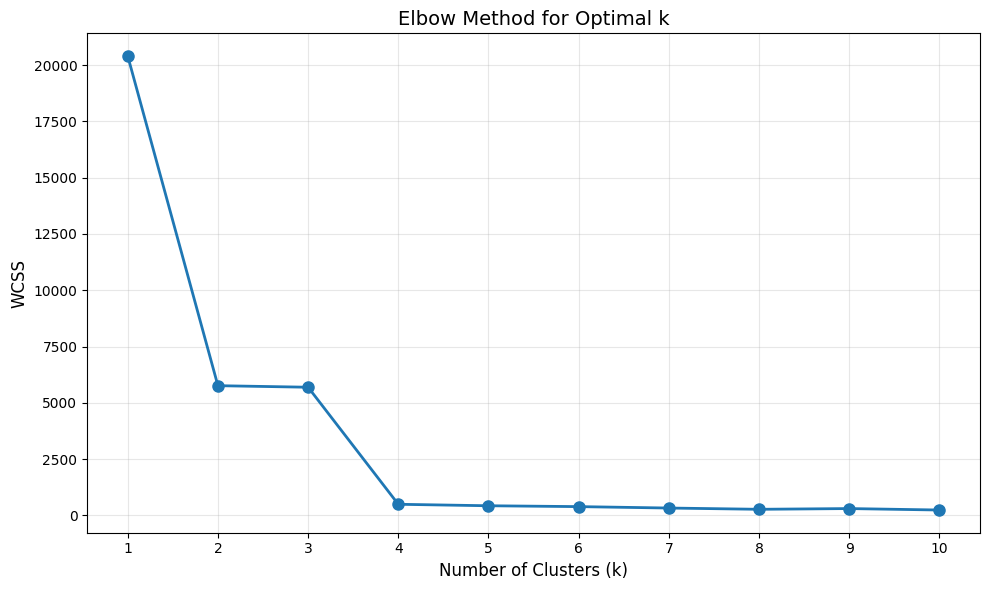

WCSS values: [20402.34375, 5763.46484375, 5694.6875, 496.9908447265625, 431.36871337890625, 393.1454772949219, 330.17864990234375, 274.1465759277344, 306.49871826171875, 241.9595947265625]


In [35]:
# Plot

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, k_max+1), results, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, k_max+1))
plt.tight_layout()
plt.show()

print(f"WCSS values: {results}")


## Observations
1. You should see different result every time due to the randomized center picking in the start
2. It does not always work perfectly as the inital center pick can be bad
3. Normally you will pick the elbow point as the ideal k